# Filtering and trimming messages

#### Review
Now, we have a deeper understanding of a few things:

- How to customize the graph state schema
- How to define custom state reducers
- How to use multiple graph state schemas

#### Goals
Now, we can start using these concepts with models in LangGraph!

In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

#### Messages as state
First, let's define some messages.

In [5]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Eyshila"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Eyshila

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm.invoke(messages)

AIMessage(content='Great! Besides whales, the ocean is teeming with other fascinating marine mammals. Here\'s a breakdown of some key groups you might want to explore, along with some interesting facts to get you started:\n\n**1. Dolphins & Porpoises (Cetaceans - Odontocetes):**\n\n*   **Why study them?** They are highly intelligent, social animals with complex communication skills. They are often seen interacting with humans and are popular subjects of research.\n*   **Key Differences:** Dolphins generally have a longer, more prominent "beak" (rostrum) than porpoises, and their teeth are cone-shaped. Porpoises tend to have shorter, more rounded faces and spade-shaped teeth. Dolphins are also generally more acrobatic.\n*   **Examples:**\n    *   **Bottlenose Dolphin:** The iconic dolphin often seen in aquariums and TV shows.\n    *   **Spinner Dolphin:** Known for their incredible aerial displays.\n    *   **Harbor Porpoise:** A smaller, more elusive porpoise found in coastal waters.\n

We can run our chat model in a simple graph with `MessagesState`.

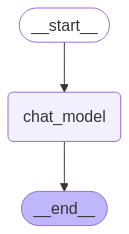

In [2]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Eyshila

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's great! Whales are fascinating. Since you're branching out beyond whales, here's a breakdown of other ocean mammal groups and some specific examples to get you started:

**1. Dolphins and Porpoises (Cetaceans - Odontocetes):**

*   **Key Differences from Whales:** Generally smaller than whales, have conical teeth (whales can have baleen plates instead), and more streamlined bodies. Dolphins tend to have longer beaks (rostrums) and curved dorsal fins, while porpoises have shorter beaks and triangular dorsal fins.
*   **Examples:**
    *   **Bottlenose Dolphin:** Highly intelligent and social, known for the

In [20]:
output["messages"][:-2]

[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='2f623db9-6634-42a9-903e-d5594a792e9b')]

#### Reducer

A practical challenge when working with messages is managing long-running conversations.

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

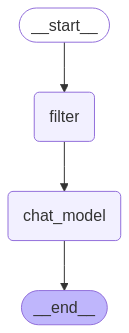

In [12]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Eyshila", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Eyshila", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Eyshila

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Okay, great! Since you know about whales, let's explore some other fascinating groups of marine mammals. Here's a breakdown of some other key groups you should learn about, along with some interesting facts to pique your interest:

**1. Dolphins and Porpoises:**

*   **Relationship to Whales:** These are both toothed whales (Odontocetes), so they're closely related to whales. Think of them as the smaller, more agile cousins.
*   **Key Differences:** Dolphins generally have longer, more prominent beaks (rostrums) and cone-shaped teeth. Porpoises have shorter beaks and spade-shaped teeth. They also tend to be sma

#### Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

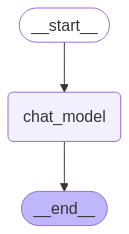

In [18]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# view
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [14]:
messages.append(output['messages'][-1])

In [16]:
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Eyshila"))

In [17]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Eyshila

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Eyshila

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Okay, great! Since you know about whales, let's explore some other fascinating groups of marine mammals. Here's a breakdown of some other key groups you should learn about, along with some interesting facts to pique your interest:

**1. Dolphins and Porpoises:**

*   **Relationship to Whales:** These are both toothed whales (Odontocetes), so they're closely related to whales. Think of them as the smaller, more agile co

In [19]:
# Invoke, using message filtering
output = graph.invoke({"messages": messages})
for m in output["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Eyshila

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Eyshila

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Okay, great! Since you know about whales, let's explore some other fascinating groups of marine mammals. Here's a breakdown of some other key groups you should learn about, along with some interesting facts to pique your interest:

**1. Dolphins and Porpoises:**

*   **Relationship to Whales:** These are both toothed whales (Odontocetes), so they're closely related to whales. Think of them as the smaller, more agile co

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message

#### Trim messages

Another approach is to [trim messages](https://python.langchain.com/v0.2/docs/how_to/trim_messages/#getting-the-last-max_tokens-tokens), based upon a set number of tokens.

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

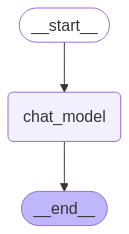

In [31]:
from langchain_core.messages import trim_messages

def chat_model_node(state: MessagesState):
    messages = trim_messages(
        state["messages"],
        max_tokens=100,
        strategy="last",
        token_counter=ChatGoogleGenerativeAI(model="gemini-2.0-flash"),
        allow_partial=False,
    )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Eyshila"))

In [24]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatGoogleGenerativeAI(model="gemini-2.0-flash"),
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Eyshila')]

In [32]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [33]:
for m in messages_out_trim["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Eyshila

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Eyshila

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Okay, great! Since you know about whales, let's explore some other fascinating groups of marine mammals. Here's a breakdown of some other key groups you should learn about, along with some interesting facts to pique your interest:

**1. Dolphins and Porpoises:**

*   **Relationship to Whales:** These are both toothed whales (Odontocetes), so they're closely related to whales. Think of them as the smaller, more agile co